# Welcome to Colab!

In [6]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
#preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [8]:
#Ml
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [9]:
df=pd.read_csv('/content/supermarket sales.csv')

In [10]:
df.head()

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Total,Date,Payment,Rating
0,West,Madurai,Member,Male,Fruits & Veggies,87.17,6,26.15,523,549.15,12-03-2018,Credit card,9.0
1,Central,Nagercoil,Normal,Female,Beverages,1301.00,1,65.05,1301,1366.05,04-03-2017,Credit card,6.2
2,West,Madurai,Normal,Female,Food Grains,288.50,4,57.70,1154,1211.70,11/29/2015,Credit card,9.2
3,Central,Cumbum,Normal,Female,"Eggs, Meat & Fish",409.00,5,102.25,2045,2147.25,12/27/2016,Cash,6.4
4,West,Ooty,Normal,Male,Beverages,213.00,3,31.95,639,670.95,4/17/2018,Cash,6.0


In [11]:
# Check dataset shape
print("Number of Rows and Columns:")
print(df.shape)

Number of Rows and Columns:
(1000, 13)


In [12]:
print(df.columns)

Index(['Branch', 'City', 'Customer type', 'Gender', 'Product line',
       'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Total', 'Date', 'Payment',
       'Rating'],
      dtype='object')


In [13]:
# Display data types
df.dtypes

,0
Branch,object
City,object
Customer type,object
Gender,object
Product line,object
Unit price,float64
Quantity,int64
Tax 5%,float64
Sales,int64
Total,float64


In [14]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Branch         1000 non-null   object 
 1   City           1000 non-null   object 
 2   Customer type  1000 non-null   object 
 3   Gender         1000 non-null   object 
 4   Product line   1000 non-null   object 
 5   Unit price     1000 non-null   float64
 6   Quantity       1000 non-null   int64  
 7   Tax 5%         1000 non-null   float64
 8   Sales          1000 non-null   int64  
 9   Total          1000 non-null   float64
 10  Date           1000 non-null   object 
 11  Payment        1000 non-null   object 
 12  Rating         1000 non-null   float64
dtypes: float64(4), int64(2), object(7)
memory usage: 101.7+ KB


In [15]:
#Check missing values
df.isnull().sum()

,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0
Total,0


In [16]:
#Convert Date column into datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.dtypes

,0
Branch,object
City,object
Customer type,object
Gender,object
Product line,object
Unit price,float64
Quantity,int64
Tax 5%,float64
Sales,int64
Total,float64


In [17]:
#Normalize numeric columns
scaler = MinMaxScaler()
columns_to_normalize = [
    'Unit price',
    'Quantity',
    'Rating'
]
df[columns_to_normalize] = scaler.fit_transform(
    df[columns_to_normalize]
)
df.head()

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Total,Date,Payment,Rating
0,West,Madurai,Member,Male,Fruits & Veggies,0.011812,0.625,26.15,523,549.15,2018-12-03,Credit card,0.833333
1,Central,Nagercoil,Normal,Female,Beverages,0.508943,0.000,65.05,1301,1366.05,2017-04-03,Credit card,0.366667
2,West,Madurai,Normal,Female,Food Grains,0.094267,0.375,57.70,1154,1211.70,NaT,Credit card,0.866667
3,Central,Cumbum,Normal,Female,"Eggs, Meat & Fish",0.143619,0.500,102.25,2045,2147.25,NaT,Cash,0.400000
4,West,Ooty,Normal,Male,Beverages,0.063346,0.250,31.95,639,670.95,NaT,Cash,0.333333


In [19]:
#Summary
df.describe()

,Unit price,Quantity,Tax 5%,Sales,Total,Date,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,403,1000.000000
mean,0.171570,0.501750,75.819950,1516.399000,1592.218950,2017-04-12 06:25:54.342431744,0.486850
min,0.000000,0.000000,25.250000,505.000000,530.250000,2015-01-06 00:00:00,0.000000
25%,0.055539,0.250000,51.500000,1030.000000,1081.500000,2016-06-09 12:00:00,0.233333
50%,0.098990,0.500000,76.000000,1520.000000,1596.000000,2017-06-05 00:00:00,0.483333
75%,0.203900,0.750000,100.862500,2017.250000,2118.112500,2018-03-09 00:00:00,0.733333
max,1.000000,1.000000,125.000000,2500.000000,2625.000000,2018-12-11 00:00:00,1.000000
std,0.195958,0.322986,28.764658,575.293169,604.057827,NaN,0.285754


In [20]:
#Nominal Features
nominal_features = [
    'Branch',
    'City',
    'Gender',
    'Customer type',
    'Product line',
    'Payment'
]
print("Nominal Features:")
print(nominal_features)

Nominal Features:
['Branch', 'City', 'Gender', 'Customer type', 'Product line', 'Payment']


In [21]:
#Ordinal Features
ordinal_features=['Rating']
print("\nOrdinal Features:")
print(ordinal_features)


Ordinal Features:
['Rating']


In [22]:
#Ratio Features
ratio_features=[
    'Total',
    'Tax 5%',
    'Quantity',
    'Unit price'
]
print("\nRatio Features:")
print(ratio_features)


Ratio Features:
['Total', 'Tax 5%', 'Quantity', 'Unit price']


In [23]:
#Train test-split
X = df[['Branch', 'Product line', 'Payment']]
y = np.where(df['Rating'] > 0.5, 1, 0)
encoder = LabelEncoder()
for col in X.columns:
    X[col] = encoder.fit_transform(X[col])
    X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (800, 3)
Testing Data Shape: (200, 3)


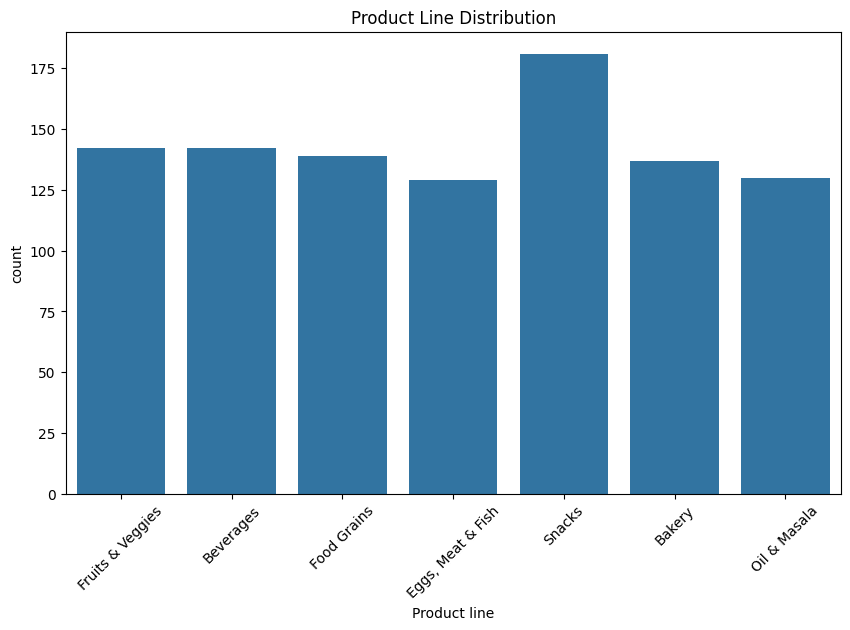

In [30]:
#Count plot of product line
plt.figure(figsize=(10,6))

sns.countplot(x='Product line', data=df)

plt.xticks(rotation=45)

plt.title("Product Line Distribution")

plt.show()

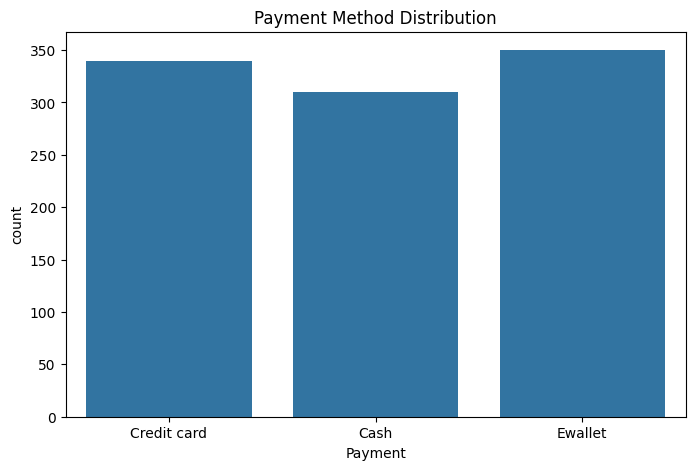

In [32]:
#Payment method distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Payment', data=df)
plt.title("Payment Method Distribution")

plt.show()

In [33]:
#Association rule using Apriori

#Association transaction table
basket = pd.crosstab(df['Branch'], df['Product line'])
# Convert values to 1 and 0
basket = basket.applymap(lambda x: 1 if x > 0 else 0)
# Apply Apriori
frequent_items = apriori(basket, min_support=0.3, use_colnames=True)
# Generate association rules
rules = association_rules(frequent_items, metric='confidence', min_threshold=0.5)
# Show rules
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
0,(Bakery),(Beverages),0.8,1.0,1.25
1,(Beverages),(Bakery),0.8,1.0,1.25
2,(Bakery),"(Eggs, Meat & Fish)",0.8,1.0,1.25
3,"(Eggs, Meat & Fish)",(Bakery),0.8,1.0,1.25
4,(Bakery),(Food Grains),0.8,1.0,1.25
...,...,...,...,...,...
1927,(Fruits & Veggies),"(Oil & Masala, Snacks, Beverages, Bakery, Food...",0.8,1.0,1.25
1928,(Beverages),"(Oil & Masala, Snacks, Fruits & Veggies, Baker...",0.8,1.0,1.25
1929,(Bakery),"(Oil & Masala, Snacks, Fruits & Veggies, Bever...",0.8,1.0,1.25
1930,(Food Grains),"(Oil & Masala, Snacks, Fruits & Veggies, Bever...",0.8,1.0,1.25


In [34]:
#Customer Clustering using K-Means
cluster_data = df[['Total', 'Quantity']]
# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(cluster_data)

cluster_names = {
    0: 'Low Value',
    1: 'Mid Value',
    2: 'High Value'
}

df['Customer Segment'] = df['Cluster'].map(cluster_names)
df[['Total', 'Quantity', 'Customer Segment']].head()

,Total,Quantity,Customer Segment
0,549.15,0.625,Mid Value
1,1366.05,0.000,Low Value
2,1211.70,0.375,Mid Value
3,2147.25,0.500,High Value
4,670.95,0.250,Mid Value


In [36]:
df['Customer Segment'].value_counts()

,count
Customer Segment,
High Value,348
Mid Value,332
Low Value,320


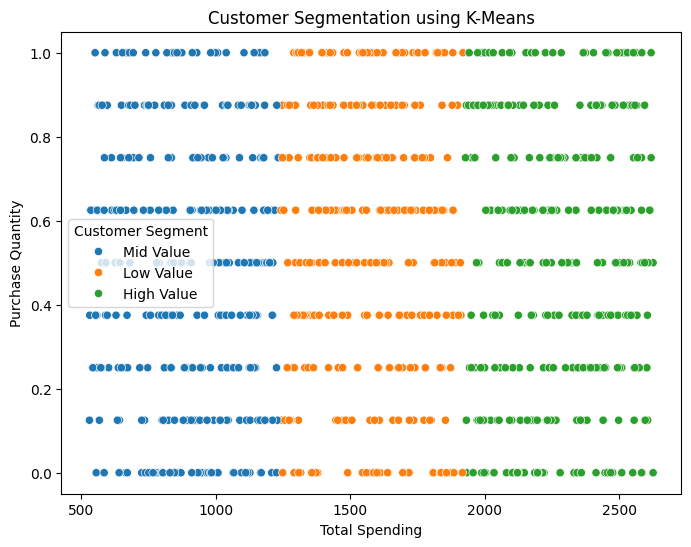

In [38]:
#Visualize customer clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Total'],
    y=df['Quantity'],
    hue=df['Customer Segment']
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Total Spending")
plt.ylabel("Purchase Quantity")
plt.show()
